In [2]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
# import shutil
# import zipfile
# from pathlib import Path

# import pandas as pd

# N = 2000
# ROOT = Path("/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized")
# OUT = Path("/kaggle/working/chestxray_subset")
# IMG_OUT = OUT / "images"
# IMG_OUT.mkdir(parents=True, exist_ok=True)

# # 1. first N filenames from the train/val list (in file order)
# with open(ROOT / "train_val_list_NIH.txt") as f:
#     filenames = [line.strip() for line in f if line.strip()][:N]
# print("Selected:", len(filenames))

# # 2. the images may sit in a subfolder, so map filename -> full path
# name_to_path = {p.name: p for p in ROOT.rglob("*.png")}
# print("Images found in dataset:", len(name_to_path))

# # 3. copy the images
# missing = []
# for name in filenames:
#     src = name_to_path.get(name)
#     if src is None:
#         missing.append(name)
#         continue
#     shutil.copy2(src, IMG_OUT / name)
# print("Copied:", len(filenames) - len(missing), "| Missing:", len(missing))

# # 4. subset CSV, keeping only the selected rows (original order preserved)
# df = pd.read_csv(ROOT / "Data_Entry_2017.csv")
# df_sub = df[df["Image Index"].isin(set(filenames))].reset_index(drop=True)
# df_sub.to_csv(OUT / "Data_Entry_2017.csv", index=False)
# print("CSV rows:", len(df_sub))

# # 5. subset txt file
# with open(OUT / "train_val_list_NIH.txt", "w") as f:
#     f.write("\n".join(filenames) + "\n")

# # 6. zip it all for download
# zip_path = Path("/kaggle/working/chestxray_subset.zip")
# with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_STORED) as zf:  # PNGs are already compressed
#     for p in OUT.rglob("*"):
#         if p.is_file():
#             zf.write(p, p.relative_to(OUT))
# print(f"Zip: {zip_path} ({zip_path.stat().st_size / 1e6:.1f} MB)")

Selected: 2000
Images found in dataset: 112120
Copied: 2000 | Missing: 0
CSV rows: 2000
Zip: /kaggle/working/chestxray_subset.zip (44.1 MB)


In [3]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms as T
import pandas as pd
import os
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

In [4]:
CLASSES = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Effusion",
    "Emphysema",
    "Fibrosis",
    "Hernia",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pleural_Thickening",
    "Pneumonia",
    "Pneumothorax",
]
label_to_idx = {
    "Atelectasis": 0,
    "Cardiomegaly": 1,
    "Consolidation": 2,
    "Edema": 3,
    "Effusion": 4,
    "Emphysema": 5,
    "Fibrosis": 6,
    "Hernia": 7,
    "Infiltration": 8,
    "Mass": 9,
    "Nodule": 10,
    "Pleural_Thickening": 11,
    "Pneumonia": 12,
    "Pneumothorax": 13,
}
# class ChestXrayDataset(Dataset):

In [5]:
df = pd.read_csv("/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/Data_Entry_2017.csv")
df


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,058Y,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,058Y,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,058Y,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,081Y,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,081Y,F,PA,2582,2991,0.143,0.143,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
112115,00030801_001.png,Mass|Pneumonia,1,30801,039Y,M,PA,2048,2500,0.168,0.168,NaN
112116,00030802_000.png,No Finding,0,30802,029Y,M,PA,2048,2500,0.168,0.168,NaN
112117,00030803_000.png,No Finding,0,30803,042Y,F,PA,2048,2500,0.168,0.168,NaN
112118,00030804_000.png,No Finding,0,30804,030Y,F,PA,2048,2500,0.168,0.168,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  object 
 5   Patient Gender               112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
 11  Unnamed: 11                  0 non-null       float64
dtypes: float64(3), int64(4), object(5)
memory usage: 10.3+ MB


In [7]:
df.shape

(112120, 12)

In [8]:
df["Finding Labels"].nunique()

790

In [9]:
df["Finding Labels"].value_counts().head(20)

Finding Labels
No Finding                           60412
Infiltration                          9551
Atelectasis                           4212
Effusion                              3959
Nodule                                2706
Pneumothorax                          2199
Mass                                  2138
Effusion|Infiltration                 1602
Atelectasis|Infiltration              1356
Consolidation                         1314
Atelectasis|Effusion                  1167
Pleural_Thickening                    1127
Cardiomegaly                          1094
Emphysema                              895
Infiltration|Nodule                    829
Atelectasis|Effusion|Infiltration      740
Fibrosis                               727
Edema                                  634
Cardiomegaly|Effusion                  483
Consolidation|Infiltration             442
Name: count, dtype: int64

In [10]:
all_labels = (
    df["Finding Labels"]
    .str.split("|")
    .explode()
)

all_labels.value_counts()

Finding Labels
No Finding            60412
Infiltration          19870
Effusion              13307
Atelectasis           11535
Nodule                 6323
Mass                   5746
Pneumothorax           5298
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2772
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1353
Hernia                  227
Name: count, dtype: int64

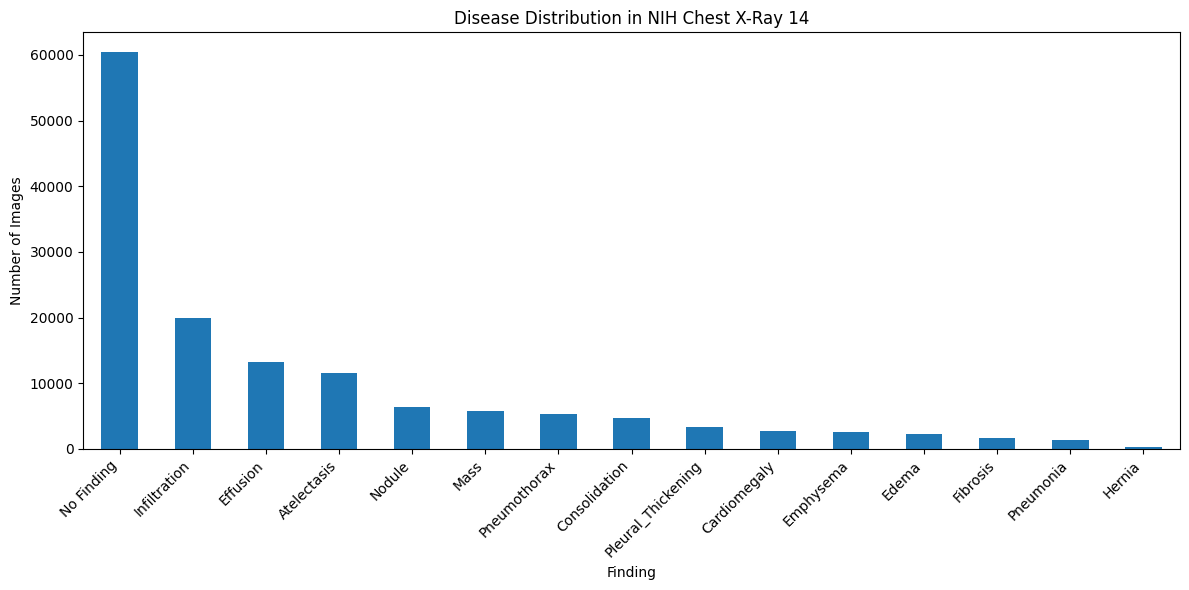

In [11]:
all_labels = (
    df["Finding Labels"]
    .str.split("|")
    .explode()
)

label_counts = all_labels.value_counts()

plt.figure(figsize=(12, 6))
label_counts.plot(kind="bar")

plt.title("Disease Distribution in NIH Chest X-Ray 14")
plt.xlabel("Finding")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

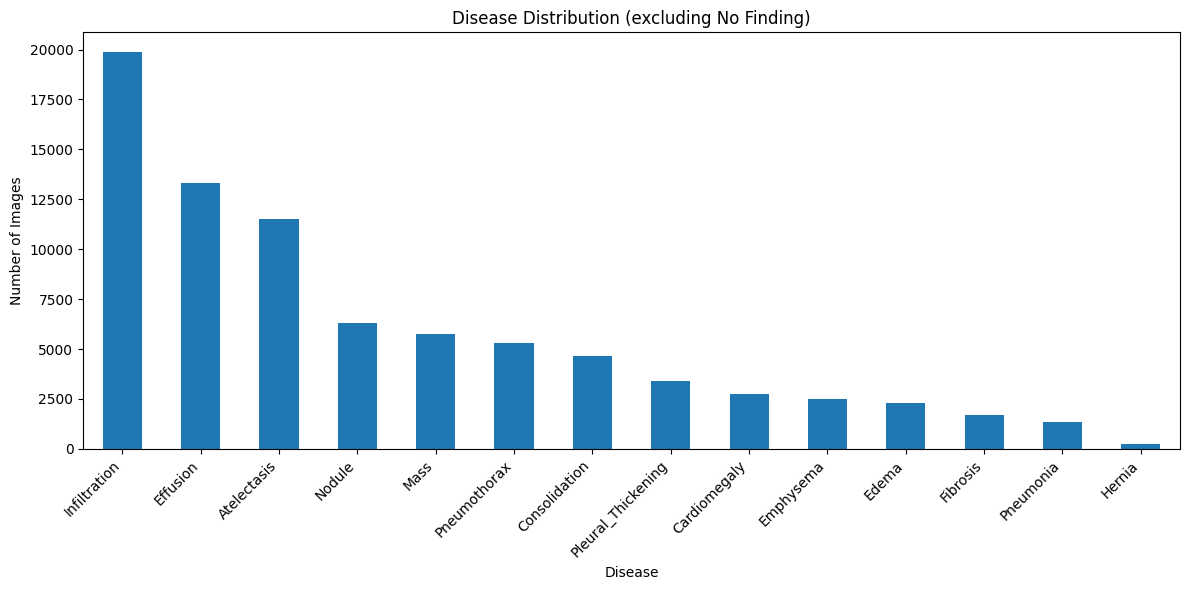

In [12]:
disease_counts = label_counts.drop("No Finding")

plt.figure(figsize=(12, 6))
disease_counts.plot(kind="bar")

plt.title("Disease Distribution (excluding No Finding)")
plt.xlabel("Disease")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Count how many diseases each image has

In [13]:
df["Finding Labels"].str.split('|').str.len()

0         1
1         2
2         2
3         1
4         1
         ..
112115    2
112116    1
112117    1
112118    1
112119    1
Name: Finding Labels, Length: 112120, dtype: int64

In [14]:
df["num_labels"] = df["Finding Labels"].str.split("|").str.len()

df["num_labels"].value_counts().sort_index()

num_labels
1    91385
2    14292
3     4829
4     1233
5      298
6       64
7       16
8        1
9        2
Name: count, dtype: int64

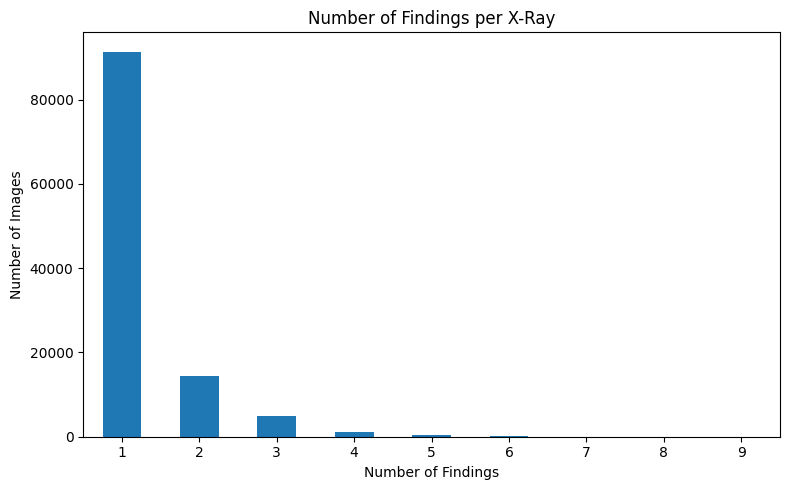

In [15]:
import matplotlib.pyplot as plt

label_counts = df["num_labels"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
label_counts.plot(kind="bar")

plt.title("Number of Findings per X-Ray")
plt.xlabel("Number of Findings")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [16]:
df[df["Finding Labels"] != "No Finding"]["num_labels"].value_counts().sort_index()

num_labels
1    30973
2    14292
3     4829
4     1233
5      298
6       64
7       16
8        1
9        2
Name: count, dtype: int64

In [17]:
cnt = 0
with open("/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/train_val_list_NIH.txt", 'r') as f:
    filenames = [
        line.strip()
        for line in f
    ]

new_df = df[df["Image Index"].isin(filenames)]
new_df.reset_index(drop=True, inplace=True)
new_df.loc[0]

Image Index                    00000001_000.png
Finding Labels                     Cardiomegaly
Follow-up #                                   0
Patient ID                                    1
Patient Age                                058Y
Patient Gender                                M
View Position                                PA
OriginalImage[Width                        2682
Height]                                    2749
OriginalImagePixelSpacing[x               0.143
y]                                        0.143
Unnamed: 11                                 NaN
num_labels                                    1
Name: 0, dtype: object

In [18]:
class ChestXrayDataset(Dataset):
    def __init__(
        self,
        images_dir: str,
        csv_file: str,
        split_file: str,
        transforms=None,
    ):
        self.images_dir = Path(images_dir)
        df = pd.read_csv(csv_file)
        self.transforms = transforms

        with open(split_file, 'r') as f:
            filenames = [
                line.strip()
                for line in f
            ]

        # get only the images that in filenames
        self.df = df[df["Image Index"].isin(filenames)].copy()
        # resent index
        self.df.reset_index(drop=True, inplace=True)

        self.classes = CLASSES
        self.cls_to_idx = {
            clss: idx
            for idx, clss in enumerate(self.classes)
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # get the entire row
        row = self.df.iloc[idx]
        # get the image
        image_name = row["Image Index"]
        img_path = self.images_dir / image_name

        img = Image.open(img_path).convert("RGB")
        if self.transforms:
            img = self.transforms(img)


        finding_labels = row["Finding Labels"]
        labels = torch.zeros(len(self.classes), dtype=torch.float32)
        if finding_labels != "No Finding":
            findings = finding_labels.split('|')
            for find in findings:
                cls_idx = self.cls_to_idx[find]
                labels[cls_idx] = 1.0

        return img, labels
        
        

In [19]:
transforms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])

In [20]:
dataset = ChestXrayDataset(
    csv_file="/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/Data_Entry_2017.csv",
    images_dir="/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/images-224/images-224",
    split_file="/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/train_val_list_NIH.txt",
    transforms=transforms,
)

In [21]:
len(dataset)

86524

In [22]:
img, labels = dataset[0]

In [23]:
img.shape

torch.Size([3, 224, 224])

In [24]:
labels

tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

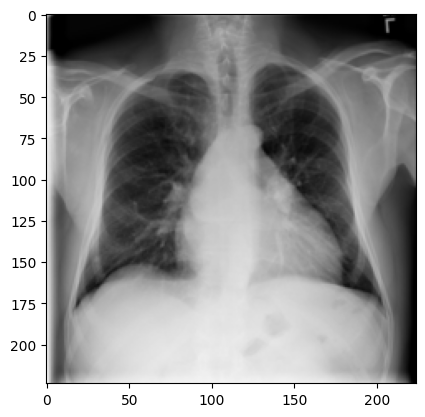

In [25]:
plt.imshow(img.permute(1, 2, 0))

In [26]:
image, labels = dataset[50]

print("Image:", dataset.df.iloc[50]["Image Index"])
print("Original labels:", dataset.df.iloc[50]["Finding Labels"])

print("\nEncoded labels:")

for disease, value in zip(dataset.classes, labels):
    if value == 1:
        print("  ✓", disease)

Image: 00000024_000.png
Original labels: Fibrosis

Encoded labels:
  ✓ Fibrosis


In [27]:
import random

for _ in range(5):

    idx = random.randint(0, len(dataset) - 1)

    image, labels = dataset[idx]
    row = dataset.df.iloc[idx]

    diseases = [
        disease
        for disease, value in zip(dataset.classes, labels)
        if value == 1
    ]

    print("=" * 60)
    print("Index:", idx)
    print("Image:", row["Image Index"])
    print("CSV labels:", row["Finding Labels"])
    print("Encoded labels:", diseases)
    print("Image shape:", image.shape)

Index: 73242
Image: 00023296_007.png
CSV labels: No Finding
Encoded labels: []
Image shape: torch.Size([3, 224, 224])
Index: 2982
Image: 00001018_007.png
CSV labels: No Finding
Encoded labels: []
Image shape: torch.Size([3, 224, 224])
Index: 6817
Image: 00002213_000.png
CSV labels: Emphysema
Encoded labels: ['Emphysema']
Image shape: torch.Size([3, 224, 224])
Index: 63446
Image: 00019717_000.png
CSV labels: Mass|Nodule
Encoded labels: ['Mass', 'Nodule']
Image shape: torch.Size([3, 224, 224])
Index: 21087
Image: 00006634_006.png
CSV labels: No Finding
Encoded labels: []
Image shape: torch.Size([3, 224, 224])


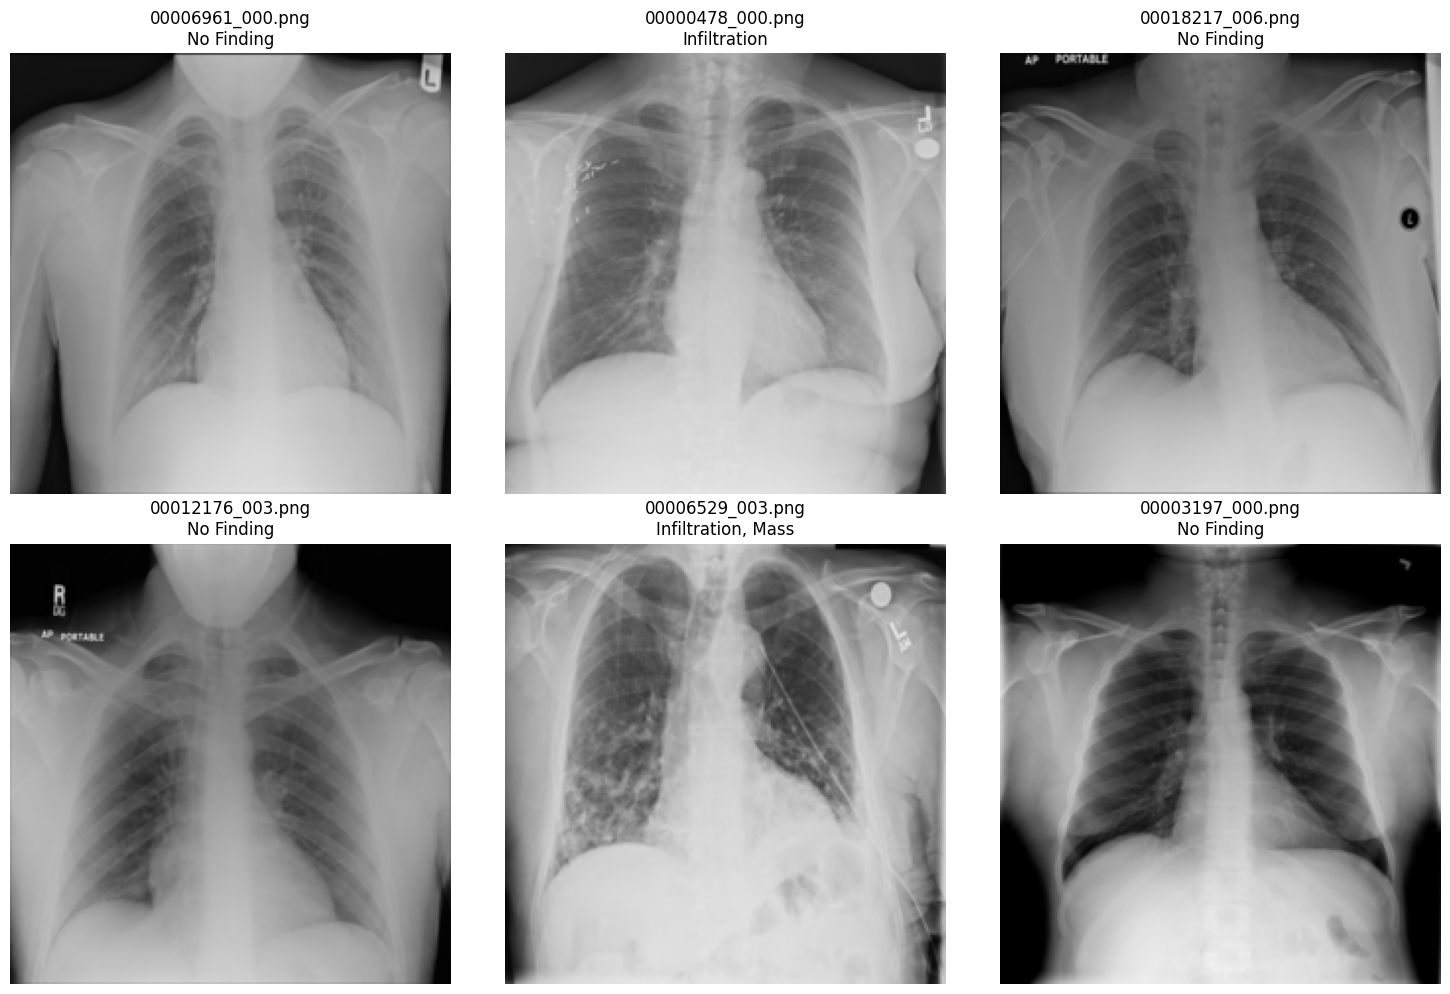

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax in axes.flat:

    idx = random.randint(0, len(dataset) - 1)

    image, labels = dataset[idx]
    row = dataset.df.iloc[idx]

    # CHW -> HWC
    image_np = image.permute(1, 2, 0).numpy()

    diseases = [
        disease
        for disease, value in zip(dataset.classes, labels)
        if value == 1
    ]

    ax.imshow(image_np)
    ax.set_title(
        f"{row['Image Index']}\n"
        + ", ".join(diseases)
        if diseases
        else f"{row['Image Index']}\nNo Finding"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [29]:
def load_data():
    dataset = ChestXrayDataset(
        csv_file="/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/Data_Entry_2017.csv",
        images_dir="/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/images-224/images-224",
        split_file="/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/train_val_list_NIH.txt",
        transforms=transforms,
    )
    # train_size = int(0.8 * len(dataset))
    # val_size = len(dataset) - train_size
    # train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    print(dataset.df["Patient ID"].nunique())
    print(len(dataset.df))
    print(
        dataset.df["Patient ID"]
        .value_counts().head(10)
    )

In [30]:
load_data()

28008
86524
Patient ID
20326    109
19176    108
10531     88
4006      81
27415     80
27725     76
10352     75
12628     73
19576     70
8468      70
Name: count, dtype: int64


In [31]:
patient_ids = df["Patient ID"].unique()

print("Number of patients:", len(patient_ids))

Number of patients: 30805


In [32]:
csv_file = "/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/Data_Entry_2017.csv"
split_file = "/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/train_val_list_NIH.txt"
image_dir = "/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/images-224/images-224"
df = pd.read_csv(csv_file)

In [33]:
with open(split_file, "r") as f:
    filenames = [line.strip() for line in f]

df = df[df["Image Index"].isin(filenames)].copy()

df.reset_index(drop=True, inplace=True)

In [34]:
patient_ids = df["Patient ID"].unique()

print("Number of patients:", len(patient_ids))

Number of patients: 28008


In [35]:
from sklearn.model_selection import train_test_split

train_patients, val_patients = train_test_split(
    patient_ids,
    test_size=0.2,
    random_state=42,
)

In [36]:
train_df = df[
    df["Patient ID"].isin(train_patients)
].copy()

val_df = df[
    df["Patient ID"].isin(val_patients)
].copy()

In [37]:
print("Train images:", len(train_df))
print("Val images:", len(val_df))

print("Train patients:", train_df["Patient ID"].nunique())
print("Val patients:", val_df["Patient ID"].nunique())

Train images: 69625
Val images: 16899
Train patients: 22406
Val patients: 5602


In [38]:
overlap = set(train_df["Patient ID"]) & set(val_df["Patient ID"])

print("Overlapping patients:", len(overlap))

Overlapping patients: 0


In [44]:
class ChestXRayDataset(Dataset):
    def __init__(
        self,
        df,
        image_dir,
        transforms=None,
    ):
        self.df = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transforms = transforms

        self.classes = CLASSES

        self.class_to_idx = {
            clss: idx
            for idx, clss in enumerate(self.classes)
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = self.image_dir / row["Image Index"]

        image = Image.open(image_path).convert("RGB")

        if self.transforms:
            image = self.transforms(image)

        labels = torch.zeros(
            len(self.classes),
            dtype=torch.float32,
        )

        if row["Finding Labels"] != "No Finding":

            findings = row["Finding Labels"].split("|")
            print(findings)

            for finding in findings:
                labels[self.class_to_idx[finding]] = 1.0

        return image, labels

In [45]:
def load_data():
    train_dataset = ChestXRayDataset(
        train_df,
        image_dir=image_dir,
        transforms=transforms,
    )
    
    val_dataset = ChestXRayDataset(
        val_df,
        image_dir=image_dir,
        transforms=transforms,
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,
    )

    return train_loader, val_loader

In [46]:
load_data()

(<torch.utils.data.dataloader.DataLoader at 0x7a6c591d4910>,
 <torch.utils.data.dataloader.DataLoader at 0x7a6c59102ea0>)